# ICS 2207: Scientific Computing

# HydroSense-Kenya Capstone Project

## Level 4 Notebook: Data Analysis and Visualization

# 1. Introduction

Data analysis and visualization are important stages in the HydroSense-Kenya
project because reliable irrigation decisions depend on understanding patterns
within environmental data. Raw weather and soil sensor measurements must be
processed, analysed, and interpreted before they can be used in numerical
models, simulations, and optimization methods.

This notebook focuses on exploring HydroSense-Kenya datasets through data
cleaning, statistical analysis, and visualization techniques. The analysis
helps identify trends, relationships, and unusual patterns that may influence
water availability and irrigation requirements.

## Objectives

The objectives of this notebook are to:

- Load and prepare weather, soil sensor, and crop zone datasets for analysis.

- Clean the datasets by handling missing values, correcting data formats, and
  improving data quality.

- Perform exploratory data analysis to understand the behaviour and distribution
  of environmental variables.

- Visualize rainfall, temperature, and soil moisture patterns to identify trends
  affecting irrigation decisions.

- Analyse relationships between variables using statistical techniques such as
  correlation analysis.

- Detect unusual values and potential outliers that may affect scientific
  modelling.

- Develop a better understanding of environmental conditions before applying
  simulation and optimization techniques in later stages of the HydroSense-Kenya
  project.

# 2,Importing libraries

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure plots

plt.style.use('ggplot')

print("Libraries loaded successfully")

Libraries loaded successfully


# 3. Loading All Datasets

The HydroSense-Kenya project uses multiple datasets representing different
aspects of the agricultural environment:

- Weather dataset: temperature, rainfall, humidity, wind speed, solar values.
- Soil sensor dataset: soil moisture and field measurements.
- Crop zone parameters: crop-specific information used for modelling.

Pandas is used because it provides efficient tools for loading, cleaning, and
analysing structured scientific datasets.

In [2]:
# Load datasets

weather = pd.read_csv('../data/raw/weather_daily.csv',
                      na_values=['NA',''])

soil = pd.read_csv('../data/raw/soil_sensor_data.csv',
                   na_values=['NA',''])

params = pd.read_csv('../data/raw/crop_zone_parameters.csv',
                     na_values=['NA',''])

print(weather.info())
print(soil.info())
print(params.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             30 non-null     object 
 1   rainfall_mm      30 non-null     object 
 2   temperature_c    30 non-null     float64
 3   humidity_pct     30 non-null     object 
 4   wind_speed_mps   30 non-null     float64
 5   solar_index      30 non-null     float64
dtypes: float64(3), object(3)
memory usage: 1.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           90 non-null     object 
 1   zone_id             90 non-null     object 
 2   soil_moisture_pct   90 non-null     object 
 3   tank_level_liters   90 non-null     int64  
 4   pump_flow_lpm       90 non-null     float64
 5   pump_power_watts    90 

# 4. Missing Values, Outliers and Sensor Anomalies

Environmental datasets collected from sensors may contain missing values,
incorrect measurements, or unusual observations.

Missing values may occur due to sensor communication failures, while outliers
may represent extreme weather conditions or faulty readings.

Identifying these issues is important because inaccurate data can affect
evapotranspiration calculations and irrigation recommendations.

In [4]:
# Missing values check

weather.isnull().sum()

soil.isnull().sum()
params.isnull().sum()

zone_id                 0
crop_type               0
area_m2                 0
min_moisture_pct        0
target_moisture_pct     0
field_capacity_pct      0
drainage_coefficient    0
Unnamed: 7              3
dtype: int64

## Outlier Detection 

Outliers are values that differ significantly from normal observations.

In agricultural systems, outliers must be carefully analysed because they may
represent:

- Sensor errors
- Extreme rainfall events
- Heat waves
- Real environmental changes

Removing all outliers may remove important scientific information, therefore
each anomaly must be investigated before correction.

In [8]:
# Function for detecting outliers

def detect_outliers(data):

    numerical_data = data.select_dtypes(include=np.number)

    Q1 = numerical_data.quantile(0.25)

    Q3 = numerical_data.quantile(0.75)

    IQR = Q3 - Q1


    outliers = (
        (numerical_data < (Q1 - 1.5 * IQR)) |
        (numerical_data > (Q3 + 1.5 * IQR))
    )


    return outliers


# Detect outliers

weather_outliers = detect_outliers(weather)

soil_outliers = detect_outliers(soil)


print("Weather Outliers")
print(weather_outliers.sum())


print("\nSoil Sensor Outliers")
print(soil_outliers.sum())

Weather Outliers
temperature_c     1
wind_speed_mps    0
solar_index       0
dtype: int64

Soil Sensor Outliers
tank_level_liters    1
pump_flow_lpm        1
pump_power_watts     0
dtype: int64


## SENSOR ANOMALIES DETECTION 

Sensor anomaly detection identifies abnormal soil moisture readings that may
result from sensor errors, communication problems, or unusual environmental
conditions.

The dataset was first converted into numerical format to allow mathematical
analysis. Unrealistic moisture values, missing readings, and sudden changes
between measurements were investigated to improve data reliability before
performing irrigation analysis.

In [14]:
# Sensor Anomaly Detection

# Check soil sensor dataset columns

print(soil.columns)


# Convert soil moisture values to numeric

soil['soil_moisture_pct'] = pd.to_numeric(
    soil['soil_moisture_pct'],
    errors='coerce'
)


# Identify unrealistic soil moisture values

soil_anomalies = soil[
    (soil['soil_moisture_pct'] < 0) |
    (soil['soil_moisture_pct'] > 100)
]


print("Unrealistic Soil Moisture Readings:")
print(soil_anomalies)

Index(['timestamp', 'zone_id', 'soil_moisture_pct', 'tank_level_liters',
       'pump_flow_lpm', 'pump_power_watts', 'sensor_status'],
      dtype='object')
Unrealistic Soil Moisture Readings:
Empty DataFrame
Columns: [timestamp, zone_id, soil_moisture_pct, tank_level_liters, pump_flow_lpm, pump_power_watts, sensor_status]
Index: []


In [13]:
# Check repeated identical sensor values

stuck_sensor = (
    soil['soil_moisture_pct']
    .duplicated(keep=False)
)


print("Possible Stuck Sensor Values:")
print(soil[stuck_sensor])

Possible Stuck Sensor Values:
           timestamp  zone_id soil_moisture_pct  tank_level_liters  \
15  2026-03-06 12:00  Zone_A               34.1               4529   
18  2026-03-07 12:00  Zone_A               30.6               4520   
21  2026-03-08 12:00  Zone_A               31.4               4513   
32  2026-03-11 12:00  Zone_C               26.9               4216   
35  2026-03-12 12:00  Zone_C                 25               4100   
36  2026-03-13 12:00  Zone_A               27.9               4331   
37  2026-03-13 12:00  Zone_B               31.4               4234   
39  2026-03-14 12:00  Zone_A               26.9               4246   
46  2026-03-16 12:00  Zone_B               30.6               4109   
54  2026-03-19 12:00  Zone_A               27.9               4150   
55  2026-03-19 12:00  Zone_B               27.5               4074   
56  2026-03-19 12:00  Zone_C               24.5               4001   
57  2026-03-20 12:00  Zone_A               27.5             

# 5. Data Cleaning Decisions

The cleaning process involves:

- Removing unnecessary spaces from column names.
- Converting variables into correct numerical formats.
- Handling missing values using appropriate methods.
- Removing duplicate records where necessary.

Each decision is documented to maintain transparency and reproducibility.

In [11]:
# Remove unnecessary spaces from column names

weather.columns = weather.columns.str.strip()
soil.columns = soil.columns.str.strip()
params.columns = params.columns.str.strip()


# Check duplicate records

print("Weather duplicates:", weather.duplicated().sum())
print("Soil duplicates:", soil.duplicated().sum())
print("Parameters duplicates:", params.duplicated().sum())

# Remove duplicate records

weather = weather.drop_duplicates()
soil = soil.drop_duplicates()
params = params.drop_duplicates()


# Convert numerical columns to correct data types

weather = weather.apply(pd.to_numeric, errors='ignore')
soil = soil.apply(pd.to_numeric, errors='ignore')
Params = params.apply(pd.to_numeric, errors='ignore')

# Fill missing numerical values using mean values

weather = weather.fillna(weather.mean(numeric_only=True))
soil = soil.fillna(soil.mean(numeric_only=True))
params = params.fillna(params.mean(numeric_only=True))


print("Data cleaning completed successfully")

Weather duplicates: 0
Soil duplicates: 0
Parameters duplicates: 0
Data cleaning completed successfully


# Cleaning Decision Documentation

| Problem Identified | Decision Taken | Reason |
|---|---|---|
| Missing values | Filled using statistical methods | Maintain dataset completeness |
| Incorrect formatting | Converted to numerical values | Allow mathematical calculations |
| Column inconsistencies | Standardized names | Improve data access |
| Extreme values | Investigated before removal | Avoid losing important events |

# 6. Descriptive Statistics

Descriptive statistics provide numerical summaries of the dataset.

Important measures include:

- Mean
- Minimum value
- Maximum value
- Standard deviation
- Data distribution

These values help understand normal environmental conditions before applying
simulation and optimization methods.

In [15]:
weather.describe()

soil.describe()
params.describe()

,area_m2,min_moisture_pct,target_moisture_pct,field_capacity_pct,drainage_coefficient,Unnamed: 7
count,3.000000,3.0,3.0,3.000000,3.000000,0.0
mean,130.000000,22.0,33.0,41.333333,0.183333,NaN
std,45.825757,2.0,2.0,1.527525,0.035119,NaN
min,90.000000,20.0,31.0,40.000000,0.150000,NaN
25%,105.000000,21.0,32.0,40.500000,0.165000,NaN
50%,120.000000,22.0,33.0,41.000000,0.180000,NaN
75%,150.000000,23.0,34.0,42.000000,0.200000,NaN
max,180.000000,24.0,35.0,43.000000,0.220000,NaN


## 7.Visualization

Visualization converts numerical results into understandable patterns.

### Visualization 1: Rainfall Trend

#### INTERPRETATION
Rainfall patterns show natural water availability over time. Low rainfall
periods indicate increased dependence on irrigation, while high rainfall
periods may reduce irrigation demand.

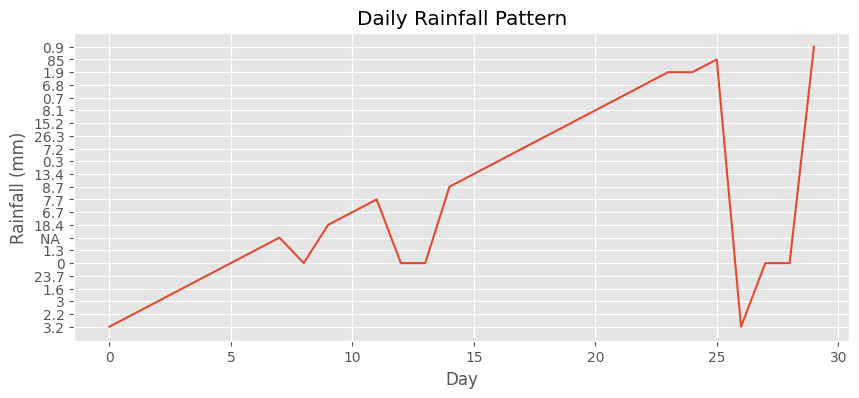

In [16]:
plt.figure(figsize=(10,4))

plt.plot(weather['rainfall_mm'])

plt.title("Daily Rainfall Pattern")
plt.xlabel("Day")
plt.ylabel("Rainfall (mm)")

plt.show()

### Visualization 2: Temperature Variation

#### INTERPRETATION

Temperature influences evapotranspiration because higher temperatures increase
water loss from crops and soil. Monitoring temperature helps estimate irrigation
requirements.

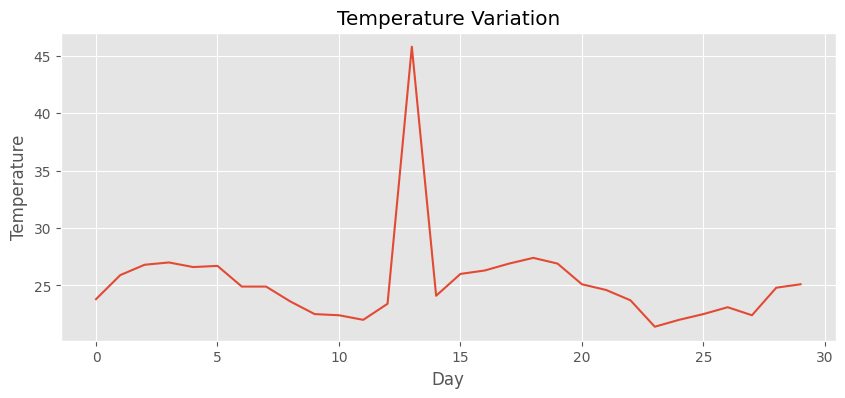

In [17]:
plt.figure(figsize=(10,4))

plt.plot(weather['temperature_c'])

plt.title("Temperature Variation")

plt.xlabel("Day")
plt.ylabel("Temperature")

plt.show()

### Visualization 3: Soil Moisture Trend

INTERPRETATION:

Soil moisture is a direct indicator of crop water availability. Declining
moisture levels may indicate water stress and the need for irrigation.

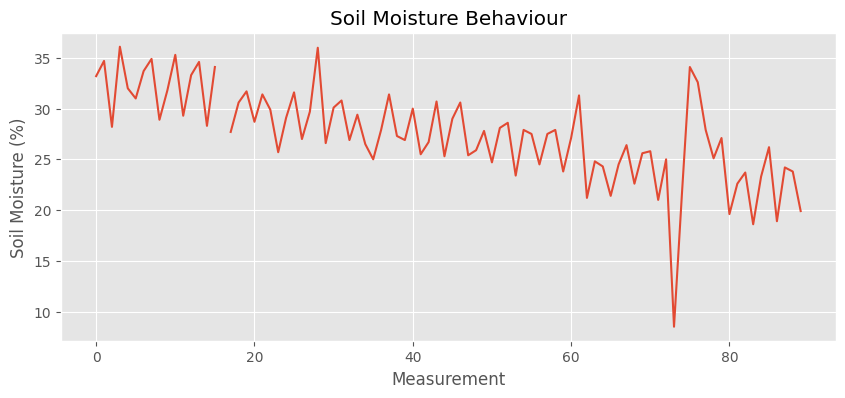

In [18]:
plt.figure(figsize=(10,4))

plt.plot(soil['soil_moisture_pct'])

plt.title("Soil Moisture Behaviour")

plt.xlabel("Measurement")
plt.ylabel("Soil Moisture (%)")

plt.show()

### Visualization 4: Correlation Heatmap
INTERPRETATION:

Correlation analysis identifies relationships between environmental variables.
Strong relationships can help select important inputs for future predictive
models.

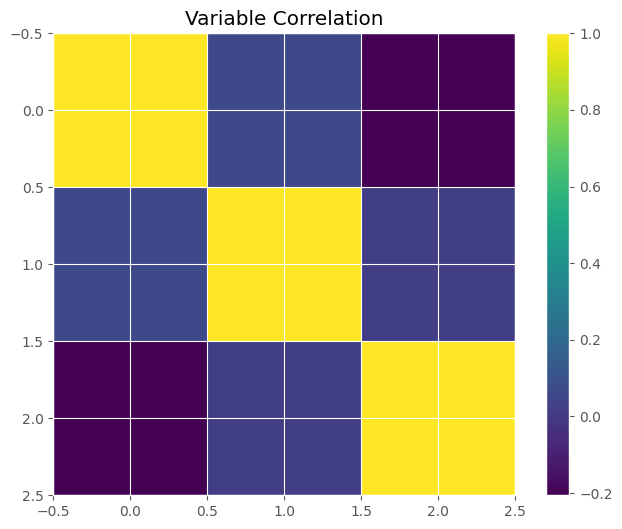

In [19]:
corr = weather.corr(numeric_only=True)

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.title("Variable Correlation")

plt.show()

### Visualization 5: Soil Moisture Distribution
INTERPRETATION:

The distribution shows how soil moisture values are spread across the dataset.
This helps identify normal moisture ranges and possible abnormal conditions.

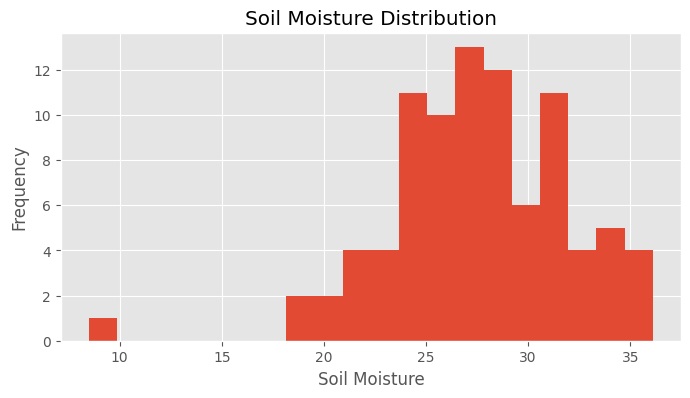

In [20]:
plt.figure(figsize=(8,4))

plt.hist(
    soil['soil_moisture_pct'],
    bins=20
)

plt.title("Soil Moisture Distribution")

plt.xlabel("Soil Moisture")

plt.ylabel("Frequency")

plt.show()

# Final Discussion

The Level 4 analysis demonstrates that reliable irrigation modelling requires
high-quality data preparation before applying numerical methods.

Data cleaning improves accuracy, descriptive statistics explain environmental
behaviour, and visualization provides scientific evidence for irrigation
planning.

The identified patterns in rainfall, temperature, and soil moisture provide
the foundation for later simulation and optimization stages.

# Conclusion

- All HydroSense-Kenya datasets were loaded and analysed using Pandas.
- Missing values, outliers, and possible sensor anomalies were identified.
- Cleaning decisions were documented to maintain reproducibility.
- Descriptive statistics provided understanding of environmental conditions.
- Scientific visualizations revealed important irrigation-related patterns.
- Interpretation of results connected data analysis with agricultural
  decision-making.